__Goal__

We will implement a linear regression model using torch.linalg

__Linear Regression Problem__

Given a sequence of input-output pairs
$$
\{(x_i, y_i): i = 1, 2, \ldots, n\},
$$
the goal is to find parameters $(w, b)$ such that the linear function
$$
y = f(x) = wx + b
$$
fits the data well. Formally, we solve:
$$
(w, b) = \arg\min_{w, b} \sum_i \left|y_i - f(x_i)\right|^2.
$$

In [13]:
# package imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import time

In [14]:
# parameters for synthetic data generation
bias_param = 5.0
weight_param = 2.0
noise_std = 3.0

In [15]:
# Create synthetic training data of size 50 and test data of size 20 (reproducible)
batch_size = 50
torch.manual_seed(42)

x_train = torch.arange(batch_size, dtype=torch.float32).reshape(-1, 1)
y_train = bias_param + weight_param * x_train + torch.randn(batch_size, 1) * noise_std

x_test = torch.arange(batch_size, batch_size + 20, dtype=torch.float32).reshape(-1, 1)
y_test = bias_param + weight_param * x_test + torch.randn(20, 1) * noise_std

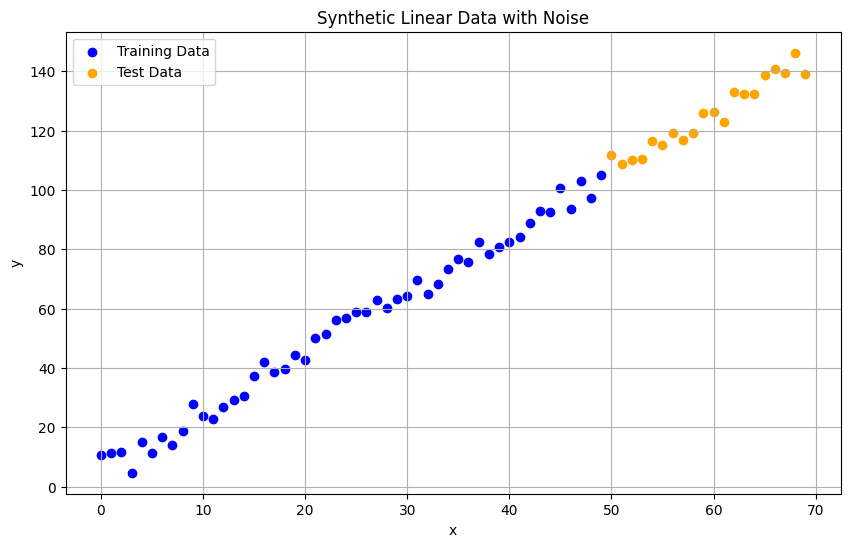

In [16]:
# plot the training and test data
plt.figure(figsize=(10, 6))
plt.scatter(x_train.numpy(), y_train.numpy(), color='blue', label='Training Data')
plt.scatter(x_test.numpy(), y_test.numpy(), color='orange', label='Test Data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Synthetic Linear Data with Noise')
plt.legend()
plt.grid()
plt.show()

__Linear Algebra approach__

Set
$$A = \begin{pmatrix}
1 & x_1 \\
1 & x_2 \\
\vdots & \vdots \\
1 & x_n
\end{pmatrix}
$$
and
$$
y = 
\begin{bmatrix}
y_1\\
y_2\\
\vdots\\
y_n
\end{bmatrix}
.$$
$(w,b)$ can be solved by
$$
A^T A 
\begin{bmatrix}
b\\
w
\end{bmatrix} = A^T y.
$$

In [17]:
# Define matrix A and vector b
A = torch.cat((torch.ones(batch_size, 1), x_train), dim=1)  # shape (batch_size, 2)
b = y_train  # shape (batch_size, 1)

# Compute the least squares solution using the normal equation
A_T = A.t()  # shape (2, batch_size)
A_T_A = A_T @ A  # shape (2, 2)
A_T_b = A_T @ b  # shape (2, 1)
theta = torch.linalg.solve(A_T_A, A_T_b)  # shape (2, 1)
print(f"Estimated parameters ([b, w]):\n{theta.squeeze()}")

Estimated parameters ([b, w]):
tensor([5.3527, 1.9973])


__MSE Loss__

Next, we evaluate solution quality using **MSE loss** on a batch of test data.  
The mathematical definition is:

$$
\mathrm{MSE}(\hat{y}, y)=\frac{1}{n}\sum_{i=1}^{n}\left(\hat{y}_i-y_i\right)^2
$$
where $\hat y$ is the prediction of $y$.

In PyTorch, we can use `nn.MSELoss` instead of defining the loss function manually.  
As expected, a smaller loss indicates better fit quality.

The code below demonstrates `nn.MSELoss` and compares it with a manually implemented MSE function based on the definition above.

In [18]:
# An simple example of MSE loss calculation
y_pred = torch.randn(3,2)  # example predictions
y_true = torch.randn(3,2)  # example true values

# Calculate MSE loss using PyTorch's built-in function
mse_loss = nn.MSELoss()
loss_value = mse_loss(y_pred, y_true)
print(f"Example MSE Loss: {loss_value.item()}")

# Recalculate MSE loss manually for the same predictions and true values
manual_loss = torch.mean((y_pred - y_true) ** 2)
print(f"Manual MSE Loss: {manual_loss.item()}")


Example MSE Loss: 0.6700615286827087
Manual MSE Loss: 0.6700615286827087


In [19]:
# Back to our linear regression example, let's compute the MSE loss for our test data using the estimated parameters
# First, we need to make predictions on the test set using the estimated parameters
b_est, w_est = theta.squeeze()  # extract bias and weight from the estimated parameters
y_test_pred = b_est + w_est * x_test  # predicted values for the test set
# Now we can compute the MSE loss on the test set
test_mse_loss = mse_loss(y_test_pred, y_test)
print(f"Test MSE Loss: {test_mse_loss.item()}")

Test MSE Loss: 9.012212753295898
